In [ ]:
import random
import sys

import matplotlib.pyplot as plt
import numpy as np

from collections import defaultdict, Counter
from IPython.display import clear_output

sys.path.append("/om2/user/bjmedina/memory/utils/")

In [68]:
import random
import numpy as np
from collections import defaultdict, Counter
import matplotlib.pyplot as plt

from IPython.display import clear_output

class ISISequence:
    def __init__(self, length=258, isi_values=[0, 1, 2, 3], seed=15):
        self.length = length
        # sequences with specific guarantees (50% repetition rate, etc), we need to enforce that the length 
        # is divisible by 3
        assert self.length % 3 == 0, "Warning: Sequence length needs to be divisible by 3"
        
        self.isi_values = isi_values
        self.seed = seed
        self.sequences = []
        self.pairs = []
        self._rng = random.Random(seed)
        self._seen_sequences = set()
        self.debug = False

    def toggle_debug(self):
        self.debug = not self.debug

        print(f"Debug switch now turned {self.debug}!")

    def generate_one(self, target_repetition_rate=0.5, min_pairs_per_isi=2):

        from collections import defaultdict

        # functions useful for Step 3: Try to upgrade non-repeats to hit the target repetition rate
        def find_upgradeable_pairs(isi_key, isi_value):
            upgrades = []
            for i in range(len(isi_key) - isi_value - 1):
                j = i + isi_value + 1
                if isi_key[i] == -1 and isi_key[j] == -1:
                    upgrades.append((i, j))
            return upgrades

        def count_nonrepeats(isi_key):
            return sum(1 for x in isi_key if x == -1)

        def count_repeats(isi_key):
            return sum(1 for x in isi_key if x >= 0) // 2

        def current_repetition_rate(num_repeats, num_nonrepeats):
            return num_repeats / (num_repeats + num_nonrepeats) 
        
        good_sequence = False
        desired_num_pairs = self.length // 3 
    
        while not good_sequence:
            
            i = 0

            isi_key = [-2] * self.length
            pairs_by_isi = defaultdict(list)
            pos_isi_values = [isi for isi in self.isi_values if isi >= 0]

            if self.debug:
                print("Before shuffling the ISIs")
                print(pos_isi_values)
            
            self._rng.shuffle(pos_isi_values)

            if self.debug:
                print("After shuffling the ISIs")
                print(pos_isi_values)
            
            isi_index = 0
            repeat_pairs_inserted = 0
    
            # Step 1: Insert as many repeat pairs as possible (with no regards to the desired number of pairs) 
            while i < self.length: #and repeat_pairs_inserted < desired_num_pairs:
                isi = pos_isi_values[isi_index % len(pos_isi_values)]
                isi_index += 1
    
                if i + isi + 1 < self.length and isi_key[i] == -2 and isi_key[i + isi + 1] == -2:
                    isi_key[i] = isi
                    isi_key[i + isi + 1] = isi
                    pairs_by_isi[isi].append((i, i + isi + 1))
                    repeat_pairs_inserted += 1
                    i += 1

                    if self.debug:
                        print(f"inserted isi of {isi} at trial {i} and {i + isi + 1}")
                else:
                    i += 1
                    if self.debug:
                        print(f"inserting isi of {isi} at trial {i} and {i + isi + 1} was not successful")

                #i = i % self.length
    
            # Step 2: Fill remaining slots as non-repeats
            for idx, val in enumerate(isi_key):
                if val == -2:
                    isi_key[idx] = -1
            
            # Step 3: Try to upgrade non-repeats to hit the target repetition rate
            # get the current rep rate
            num_nonrepeats = count_nonrepeats(isi_key)
            num_repeats    = count_repeats(isi_key)
            
            current_rate   = current_repetition_rate(num_repeats, num_nonrepeats)

            while not current_rate == target_repetition_rate:
    
                if current_rate < target_repetition_rate:
    
                    if self.debug:
                       print(f"Current repetition rate {current_rate}")
                    
                    #clear_output(wait=False)
                    #continue
                    self._rng.shuffle(pos_isi_values)
        
                    #while not current_rate == target_repetition_rate:
                    isi = pos_isi_values[isi_index % len(pos_isi_values)]
                    isi_index += 1
                    upgrade_candidates = find_upgradeable_pairs(isi_key, isi)
                    self._rng.shuffle(upgrade_candidates)
                    
                    if len(upgrade_candidates) > 0:
    
                        # Upgrade this pair
                        i1, i2 = upgrade_candidates[-1]
                            
                        isi_key[i1] = isi
                        isi_key[i2] = isi
                        pairs_by_isi[isi].append((i1, i2))
                        repeat_pairs_inserted += 1

                        if self.debug:
                           print(f"Added ({i1}, {i2})")
                        
                        # check the current repetition rate
                        num_nonrepeats = count_nonrepeats(isi_key)
                        num_repeats    = count_repeats(isi_key)
                        current_rate   = current_repetition_rate(num_repeats, num_nonrepeats)
                    
                    if self.debug:
                        print(f" Rep. Rate after additions = {current_rate}")
    
                elif current_rate > target_repetition_rate:
    
                    if self.debug:
                       print(f"Current repetition rate {current_rate}")
                        
                    # GOAL: 
                    # we want to remove pairs until we get to the target reptition rate
                    # particularly the ones that are overrepresented (so if one ISI has a lot of representation in 'pairs_by_isi', i'd like to randomly replace one of those
                    # trials with two non-repeat trials 
                    
                    # Compute how many repeat pairs to remove
                    num_nonrepeats = count_nonrepeats(isi_key)
                    num_repeats = count_repeats(isi_key)
                    excess = num_repeats - int(target_repetition_rate * (num_repeats + num_nonrepeats))
                
                    # Flatten all pairs
                    all_pairs = [(isi, pair) for isi, pairs in pairs_by_isi.items() for pair in pairs]
                    # Sort by overrepresentation
                    all_pairs.sort(key=lambda x: -len(pairs_by_isi[x[0]]))
                    self._rng.shuffle(all_pairs)  # Optional: add noise to avoid bias
                
                    removed = 0
                    for isi, (i1, i2) in all_pairs:
                        if removed >= excess:
                            break
                        if isi_key[i1] == isi and isi_key[i2] == isi:
                            isi_key[i1] = -1
                            isi_key[i2] = -1
                            pairs_by_isi[isi].remove((i1, i2))
                            removed += 1
                            if self.debug:
                               print(f"Removed ({i1}, {i2}).")
                
                    # Recompute rate
                    num_nonrepeats = count_nonrepeats(isi_key)
                    num_repeats = count_repeats(isi_key)
                    current_rate = current_repetition_rate(num_repeats, num_nonrepeats)
                    if self.debug:
                        print(f" Rep. Rate after removals = {current_rate}")


            # Step 3a: Try to add more repeat pairs to underrepresented ISIs
            for isi in pos_isi_values:
                while len(pairs_by_isi[isi]) < min_pairs_per_isi:
                    upgrade_candidates = find_upgradeable_pairs(isi_key, isi)
                    self._rng.shuffle(upgrade_candidates)
                    if not upgrade_candidates:
                        if self.debug:
                            print(f"⚠️ No more upgradeable pairs available for ISI {isi}")
                        break  # can't add more to this ISI
            
                    i1, i2 = upgrade_candidates.pop()
                    isi_key[i1] = isi
                    isi_key[i2] = isi
                    pairs_by_isi[isi].append((i1, i2))
            
                    if self.debug:
                        print(f"✅ Added ({i1}, {i2}) to ISI {isi} (to reach {min_pairs_per_isi})")
            
            # Step 3b: Prune overrepresented ISIs to enforce exact per-ISI balance
            if self.debug:
                for isi in pos_isi_values:
                    print(f"# Pairs for each #IS condition {isi}: {len(pairs_by_isi[isi])}")
                          
            for isi in pos_isi_values:
                while len(pairs_by_isi[isi]) > min_pairs_per_isi:
                    self._rng.shuffle(pairs_by_isi[isi])
                    i1, i2 = pairs_by_isi[isi].pop()
                    isi_key[i1] = -1
                    isi_key[i2] = -1
                    if self.debug:
                        print(f"❌ Pruned ({i1}, {i2}) from #IS {isi} (exceeded {min_pairs_per_isi})")

            for isi in pos_isi_values:
                while len(pairs_by_isi[isi]) < min_pairs_per_isi:
                    upgrade_candidates = find_upgradeable_pairs(isi_key, isi)
                    self._rng.shuffle(upgrade_candidates)
                    if not upgrade_candidates:
                        if self.debug:
                            print(f"⚠️ No more upgradeable pairs available for #IS {isi}")
                        break  # can't add more to this ISI
            
                    i1, i2 = upgrade_candidates.pop()
                    isi_key[i1] = isi
                    isi_key[i2] = isi
                    pairs_by_isi[isi].append((i1, i2))
            
                    if self.debug:
                        print(f"✅ Added ({i1}, {i2}) to ISI {isi} (to reach {min_pairs_per_isi})")

            if self.debug:
                for isi in pos_isi_values:
                    print(f"# Pairs for ISI {isi}: {len(pairs_by_isi[isi])}")
            

            num_nonrepeats = count_nonrepeats(isi_key)
            num_repeats = count_repeats(isi_key)
            current_rate = current_repetition_rate(num_repeats, num_nonrepeats)

            if self.debug:
                print(f"Final repetition rate: {current_rate}")
            
            good_sequence = all(len(pairs_by_isi[isi]) >= min_pairs_per_isi for isi in pos_isi_values)
            if not good_sequence and self.debug:
                print("⚠️ Not all ISIs met the minimum requirement. Regenerating...")
                clear_output(wait=False)

            if not good_sequence:
                clear_output(wait=False)
        
        if self.debug:
            print("CURRENT REPETITION RATE", current_rate)
            print("AFTER:")
            print(isi_key)
            print(pairs_by_isi)
            
        #self.sequences.append(isi_key)
        seq_tuple = tuple(isi_key)
        if seq_tuple not in self._seen_sequences:
            self._seen_sequences.add(seq_tuple)
            self.sequences.append(isi_key)

            for key in pairs_by_isi:
                pairs_by_isi[key] = sorted(pairs_by_isi[key])

            for isi_key_pos, isi in enumerate(isi_key):
                if isi == -1:
                    pairs_by_isi[isi].append(isi_key_pos)

            #pairs_by_isi = sorted(pairs_by_isi)
            pairs_by_isi = {k: pairs_by_isi[k] for k in sorted(pairs_by_isi)}
                    
            self.pairs.append(pairs_by_isi)
        else:
            if self.debug:
                print("⚠️ Duplicate sequence detected. Regenerating...")
                
                
            return self.generate_one(target_repetition_rate, min_pairs_per_isi)
        return isi_key, pairs_by_isi

    def generate_n(self, n, target_repetition_rate=0.5, min_pairs_per_isi=2):
        cumulative_counts = Counter()
    
        for _ in range(n):
            self.seed += 1
            self._rng.seed(self.seed)
    
            isi_key, pairs_by_isi = self.generate_one(
                target_repetition_rate=target_repetition_rate, 
                min_pairs_per_isi=min_pairs_per_isi
            )
    
            #self.sequences.append(isi_key)  # store it
    
            for isi in isi_key:
                if isi >= 0:
                    cumulative_counts[isi] += 1
                else:
                    cumulative_counts[-1] += 1  # track nonrepeats
    
        print("Aggregate ISI usage across all sequences:")
        for isi in sorted(cumulative_counts):
            print(f"  ISI {isi}: {cumulative_counts[isi]}")

    def summary_across(self):
        combined = Counter()
        for isi_key in self.sequences:
            combined.update(Counter(isi_key))
        return dict(combined)

    def get_sequence_and_isi_pairings(self, sequence_id):
        return self.sequences[sequence_id], self.pairs[sequence_id]

    def check_balance(self, verbose=True):
        import numpy as np
    
        summary = self.summary_across()
        pos_isis = [isi for isi in self.isi_values if isi >= 0]
        counts = np.array([summary.get(isi, 0) for isi in pos_isis])
        mean_counts = np.mean(counts)
    
        if verbose:
            print("Total ISI counts across sequences:")
            for isi, count in zip(pos_isis, counts):
                print(f"ISI {isi}: {count}")
    
        mean = np.mean(counts)
        std = np.std(counts)
    
        z_scores = (counts - mean) / std if std > 0 else np.zeros_like(counts)
        max_deviation = np.max(np.abs(z_scores))
    
        if max_deviation > 1:
            print(f"⚠️ ISI imbalance detected (max z-score = {max_deviation:.2f})")
        else:
            print("✅ ISI conditions are statistically balanced (within 1 std deviation).")
        
    def clear_sequences(self):
        """Remove all stored sequences."""
        self.sequences = []

    def plot_summary(self, title="ISI Distribution Across Sequences (n={}, seq. length={})"):
        """Plot a bar chart of ISI usage across all stored sequences."""
        summary = self.summary_across()
    
        # Separate ISI values and counts
        isi_vals = sorted(summary.keys())
        counts = [summary[isi] for isi in isi_vals]
    
        # Plot
        plt.figure(figsize=(8, 5))
        plt.bar([str(isi) for isi in isi_vals], counts, alpha=0.5)
        plt.xlabel("ISI Value")
        plt.ylabel("Number of Trials")
        plt.title(title.format(len(self.sequences), self.length))
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    def plot_avg_isi_across_sequences(self):
        """Plot the average ISI value (excluding -1s) across all stored sequences."""
        import matplotlib.pyplot as plt
        import numpy as np
    
        avg_isis = [
            np.mean([isi for isi in seq if isi >= 0]) if any(isi >= 0 for isi in seq) else 0
            for seq in self.sequences
        ]

        valid_isi_values = [isi for isi in self.isi_values if isi >= 0]
        empirical_avg = np.mean(avg_isis)
        theoretical_avg = np.mean(valid_isi_values)
        
        plt.figure(figsize=(6, 4))
        plt.plot(avg_isis, marker='o', alpha=0.5)
        plt.axhline(y=theoretical_avg, color='red', linestyle='--', label=f'Theoretical Avg = {theoretical_avg:.2f}')
        plt.axhline(y=empirical_avg, color='m', linestyle='--', label=f'Empirical Avg = {empirical_avg:.2f}')        
        plt.xlabel("Sequence Index")
        plt.ylabel("Average ISI (excluding -1)")
        plt.title("Avg. ISI per Sequence")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_avg_position_of_repeats(self):
        """Plot the average position of repeated trials in each sequence."""
        import matplotlib.pyplot as plt
        import numpy as np
    
        avg_positions = [
            np.mean([i for i, isi in enumerate(seq) if isi >= 0]) if any(isi >= 0 for isi in seq) else 0
            for seq in self.sequences
        ]

        theoretical_avg = np.mean(np.arange(self.length))
        empirical_avg = np.mean(avg_positions)

        plt.figure(figsize=(6, 4))
        plt.plot(avg_positions, marker='o', alpha=0.5)
        plt.axhline(y=theoretical_avg, color='red', linestyle='--', label=f'Theoretical Avg = {theoretical_avg:.2f}')
        plt.axhline(y=empirical_avg, color='m', linestyle='--', label=f'Empirical Avg = {empirical_avg:.2f}')

        plt.xlabel("Sequence Index")
        plt.ylabel("Average Position of Repeats")
        plt.title("Avg. Position of Repeat Trials")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()



    def plot_num_repeats_per_sequence(self):
        """Plot the number of repeated stimuli (pairs) per sequence."""
        import matplotlib.pyplot as plt
    
        num_repeats = [sum(isi >= 0 for isi in seq) // 2 for seq in self.sequences]
    
        plt.figure(figsize=(6, 4))
        plt.plot(num_repeats, marker='o')
        plt.xlabel("Sequence Index")
        plt.ylabel("Number of Repeat Stimuli")
        plt.title("Number of Repeats per Sequence")
        plt.grid(True)
        plt.tight_layout()
        plt.show()




    def plot_isi_position_bias(self, bins=4):
        """
        Visualize ISI distributions across positions in the sequence to detect ISI-specific biases.
        """
        import matplotlib.pyplot as plt
        import numpy as np
        from collections import defaultdict
    
        sequence_length = len(self.sequences[0])
        bin_edges = np.linspace(0, sequence_length, bins + 1, dtype=int)
        isi_labels = sorted({isi for seq in self.sequences for isi in seq if isi >= 0})
    
        counts = {isi: np.zeros(bins) for isi in isi_labels}
    
        for seq in self.sequences:
            for b in range(bins):
                start, end = bin_edges[b], bin_edges[b + 1]
                for i in range(start, end):
                    isi = seq[i]
                    if isi >= 0:
                        counts[isi][b] += 1
    
        # Normalize to get proportions
        totals = np.sum(list(counts.values()), axis=0)
        proportions = {isi: counts[isi] / (totals + 1e-9) for isi in isi_labels}
    
        # Plot
        plt.figure(figsize=(8, 5))
        for isi in isi_labels:
            plt.plot(range(bins), proportions[isi], marker='o', label=f"ISI {isi}")
    
        # Add ideal reference line
        ideal_proportion = 1 / len(isi_labels)
        plt.axhline(ideal_proportion, color='gray', linestyle='--', alpha=0.7, label=f"Ideal = {ideal_proportion:.3f}")
    
        plt.xlabel("Sequence Bin (Position)")
        plt.ylabel("Proportion of ISI Trials")
        plt.title("Distribution of ISI Conditions Across Sequence Positions")
        plt.xticks(range(bins), [f"Bin {i+1}" for i in range(bins)])
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()



    def plot_repetition_rate_per_sequence(self):
        import matplotlib.pyplot as plt
    
        repetition_rates = []
        for seq in self.sequences:
            num_repeats = sum(isi >= 0 for isi in seq) // 2
            num_nonrepeats = sum(isi == -1 for isi in seq)
            total_pairs = num_repeats + num_nonrepeats
            rate = num_repeats / total_pairs
            repetition_rates.append(rate)
    
        plt.figure(figsize=(6, 4))
        plt.plot(repetition_rates, marker='o')
        plt.axhline(0.5, color='red', linestyle='--', label="Target = 0.5")
        plt.xlabel("Sequence Index")
        plt.ylabel("Repetition Rate")
        plt.title("Repetition Rate per Sequence")
        plt.ylim(0, 1)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()



    def plot_isi_temporal_spread(self, bins=5):
        """
        For each ISI, show how its trials are distributed across sequence positions (bins).
        Y-axis shows, for each ISI, what fraction of its trials fall into each bin.
        """
        import matplotlib.pyplot as plt
        import numpy as np
        from collections import defaultdict
    
        sequence_length = len(self.sequences[0])
        bin_edges = np.linspace(0, sequence_length, bins + 1, dtype=int)
        isi_labels = sorted({isi for seq in self.sequences for isi in seq if isi >= 0})
    
        counts = {isi: np.zeros(bins) for isi in isi_labels}
    
        # Count how many times each ISI appears in each bin
        for seq in self.sequences:
            for b in range(bins):
                start, end = bin_edges[b], bin_edges[b + 1]
                for i in range(start, end):
                    isi = seq[i]
                    if isi >= 0:
                        counts[isi][b] += 1
    
        # Normalize by total count per ISI
        proportions = {}
        for isi in isi_labels:
            total = np.sum(counts[isi])
            if total > 0:
                proportions[isi] = counts[isi] / total
            else:
                proportions[isi] = np.zeros(bins)
    
        # Plot
        plt.figure(figsize=(8, 5))
        for isi in isi_labels:
            plt.plot(range(bins), proportions[isi], marker='o', label=f"ISI {isi}")
    
        plt.xlabel("Sequence Bin (Position)")
        plt.ylabel("Proportion of ISI Occurrences")
        plt.title("Temporal Spread of Each ISI Across Sequence Bins")
        plt.xticks(range(bins), [f"Bin {i+1}" for i in range(bins)])
        plt.axhline(1/bins, color='gray', linestyle='--', alpha=0.5, label="Ideal = uniform")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def check_for_duplicate_sequences(self):
        from collections import Counter
    
        seq_tuples = [tuple(seq) for seq in self.sequences]
        counts = Counter(seq_tuples)
        duplicates = {k: v for k, v in counts.items() if v > 1}
    
        if duplicates:
            print("⚠️ Duplicate sequences found:")
            for seq, count in duplicates.items():
                print(f"  Occurs {count} times")
        else:
            print("✅ No duplicate sequences.")


class StimulusManager:
    def __init__(self, stimulus_ids, isi_values, length=258, seed=5):
        self._rng = random.Random(seed)
        self.stimulus_ids = list(stimulus_ids)
        self._rng.shuffle(self.stimulus_ids)
        self.n = length
        self.isi_values = sorted(isi_values)
        self.seq_index = 0
        self.assignment_log = []
        self.debug = False
        self.stimulus_rotation_step = self.n // (3 * (len(self.isi_values) - 1))  # exclude -1
        self.stimulus_offset = 0

    def toggle_debug(self):
        self.debug = not self.debug
        print(f"Debug switch now turned {self.debug}!")

    def get_assignments_from_pairs(self, pairs_by_isi):
        """
        Assign stimuli deterministically to ISI conditions using rotation and pair counts.
        """
        assignments = [-1] * self.n
        assignment_log = {}

        # Roll stimulus list by offset based on sequence number
        rolled = np.roll(self.stimulus_ids, -self.stimulus_offset)#np.roll(self.stimulus_ids, -sum(len(log) for log in self.assignment_log))
        pointer = 0
        self.stimulus_offset = (self.stimulus_offset + self.stimulus_rotation_step) % len(self.stimulus_ids)
        
        # Track which indices are already assigned
        for isi in sorted(pairs_by_isi):
            
            entries = pairs_by_isi[isi]
            
            if self.debug:
                print(isi, entries)
                print("\n")
            
            for item in entries:
                stim = rolled[pointer]
                pointer += 1

                if isinstance(item, tuple):  # Repeat trial (i1, i2)
                    i1, i2 = item
                    assignments[i1] = stim
                    assignments[i2] = stim
                    assignment_log[stim] = {'isi': isi, 'type': 'repeat'}
                else:  # Non-repeat trial (just one index)
                    i = item
                    assignments[i] = stim
                    assignment_log[stim] = {'isi': isi, 'type': 'nonrepeat'}
                
        if any(a == -1 for a in assignments):
            raise RuntimeError("Unassigned positions remain.")

        assignment_log = dict(sorted(assignment_log.items()))

        self.assignment_log.append(assignment_log)
        self.seq_index += 1
        return assignments


    def save_current_assignments(self, base_path=""):

        # need to get the stim set
        data = {}
        data["repetition_rate"] = rep_rate
        data["order"] = seq
        data["filenames_order"] = seq_filenames
        data["yt_id"] = yt_id
        data["isi"]   = isi_key 
        data["key"]   = getAnswerKey(seq)

        pass

    def save_current_assignments_texture_vs_exemplar(self):
        pass

    def check_isi_rotation(self):
        if len(self.assignment_log) < 2:
            print("Not enough sequences to check rotation.")
            return
    
        isi_order = sorted(self.isi_values)
        prev_log = self.assignment_log[-2]
        curr_log = self.assignment_log[-1]
        errors = []
    
        for stim, prev_info in prev_log.items():
            if stim in curr_log:
                curr_info = curr_log[stim]
                # Only check if both are repeat trials
                if prev_info['type'] == 'repeat' and curr_info['type'] == 'repeat':
                    prev_isi = prev_info['isi']
                    curr_isi = curr_info['isi']
    
                    # What ISI should come next in the cycle?
                    prev_index = isi_order.index(prev_isi)
                    expected_next_isi = isi_order[(prev_index + 1) % len(isi_order)]
    
                    if curr_isi != expected_next_isi:
                        errors.append((stim, prev_isi, curr_isi, expected_next_isi))
    
        if not errors:
            print("✅ All repeat stimuli rotated ISI correctly.")
        else:
            print("⚠️ ISI rotation mismatch found:")
            for stim, prev, curr, expected in errors:
                print(f"  Stim {stim}: was ISI {prev}, now ISI {curr}, expected ISI {expected}")

    def plot_stimulus_isi_history(self, max_stimuli=10):
        """
        Plot how ISI assignments changed over time for selected stimuli.
        Shows if ISI assignments cycle across sequences.
    
        Args:
            max_stimuli (int): Number of stimuli to visualize.
        """
        stim_to_isi_history = defaultdict(list)
    
        # Gather ISI history for each stimulus across sequences
        for seq_idx, log in enumerate(self.assignment_log):
            for stim, entry in sorted(log.items()):
                stim_to_isi_history[stim].append((seq_idx, entry['isi']))
    
        # Select up to max_stimuli for plotting
        selected_stims = list(stim_to_isi_history.keys())[:max_stimuli]
    
        # Plot
        plt.figure(figsize=(10, 5))
        for stim in selected_stims:
            points = stim_to_isi_history[stim]
            x = [seq for seq, _ in points]
            y = [isi for _, isi in points]
            plt.plot(x, y, marker='o', label=f"Stim {stim}", alpha=0.25)
    
        plt.xlabel("Sequence Index")
        plt.ylabel("Assigned ISI")
        plt.title("ISI Assignment History per Stimulus")
        plt.yticks(sorted(self.isi_values))
        plt.xticks(range(len(self.assignment_log)))  # Force integer ticks
        plt.grid(True, linestyle='--', alpha=0.5)
        
        if max_stimuli <= 10:
            plt.legend(title="Stimulus ID", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

In [86]:
len_exp = 252 # needs to be a multiple of 3 (2 non-repeat, 1 repeat trials -> three trials)
ISI_conditions = [-1, 0, 1, 2, 3, 4, 8] 

total_pairs_of_repeat_stimuli = len_exp / 3 
exact_pairs_per_isi = int(total_pairs_of_repeat_stimuli / (len(ISI_conditions) - 1)) #len(ISI_conditions) - 1 because we don't count the -1 isi condition (nonrepeats)

manager = ISISequence(length=len_exp, 
                      isi_values=ISI_conditions, 
                      seed=14)

#manager.toggle_debug()

print(min_pairs_per_isi)

14


In [87]:
manager.generate_n(100, 
                   target_repetition_rate=0.5, 
                   min_pairs_per_isi=exact_pairs_per_isi)

Aggregate ISI usage across all sequences:
  ISI -1: 8400
  ISI 0: 2800
  ISI 1: 2800
  ISI 2: 2800
  ISI 3: 2800
  ISI 4: 2800
  ISI 8: 2800


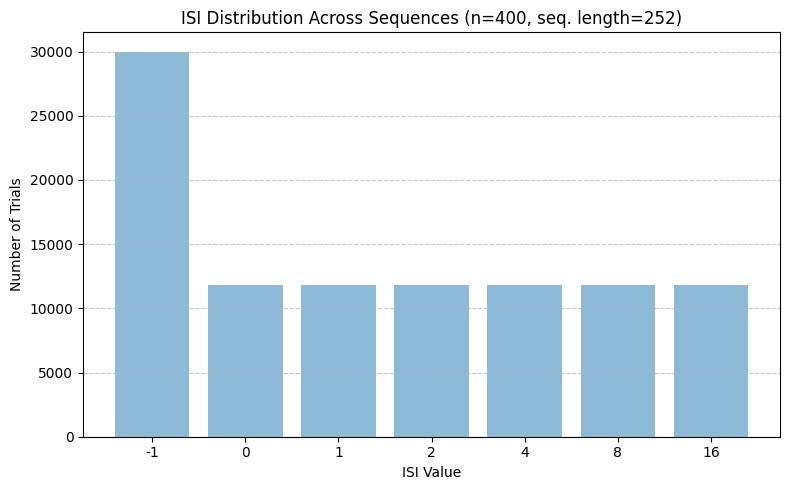

In [82]:
manager.plot_summary()

In [83]:
manager.check_for_duplicate_sequences()

✅ No duplicate sequences.


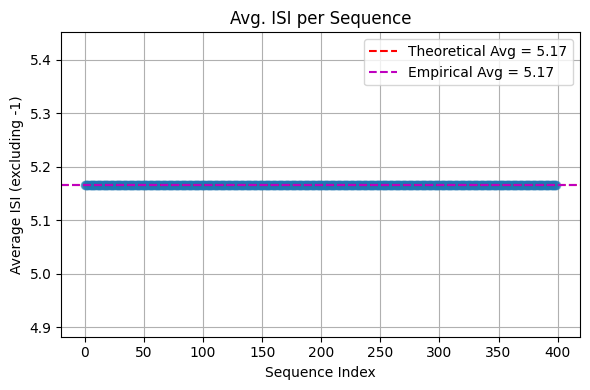

In [84]:
#plot_avg_isi_across_sequences, plot_avg_position_of_repeats, plot_num_repeats_per_sequence, plot_isi_position_bias, plot_repetition_rate_per_sequence, plot_isi_temporal_spread, check_for_duplicate_sequences
manager.plot_avg_isi_across_sequences()

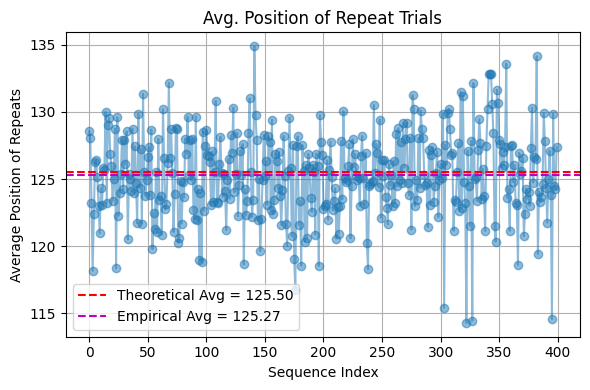

In [85]:
manager.plot_avg_position_of_repeats()

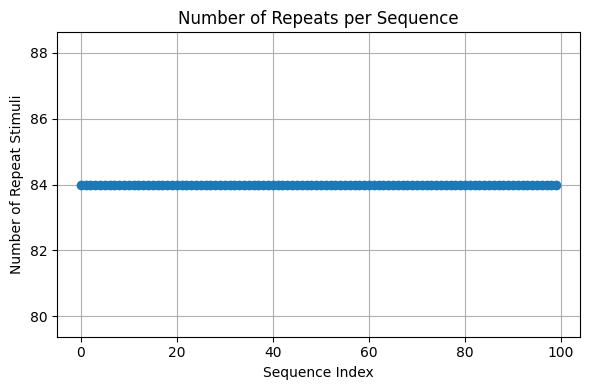

In [62]:
manager.plot_num_repeats_per_sequence()

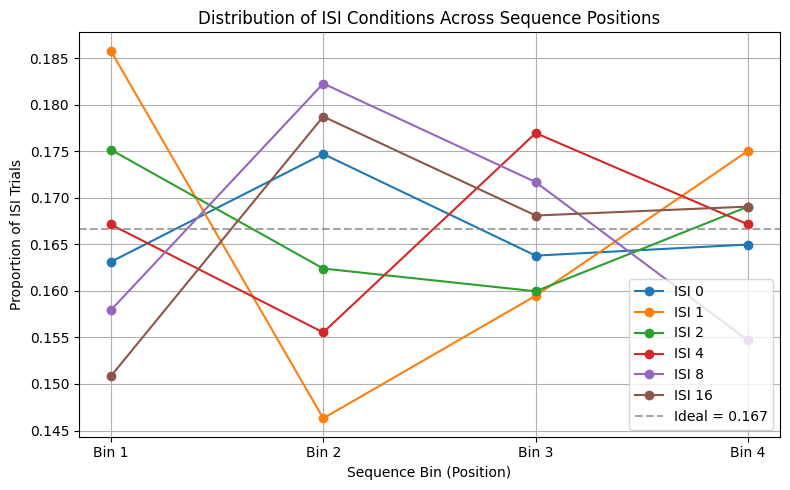

In [63]:
manager.plot_isi_position_bias()

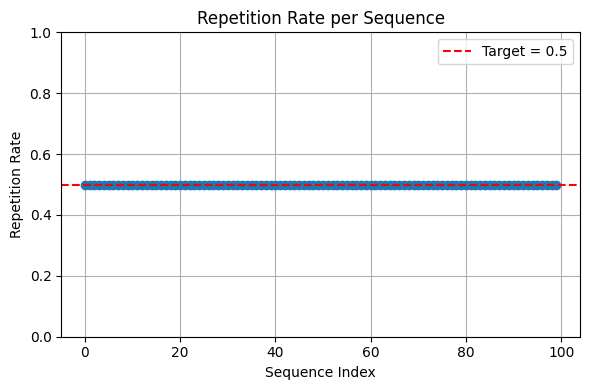

In [64]:
manager.plot_repetition_rate_per_sequence()

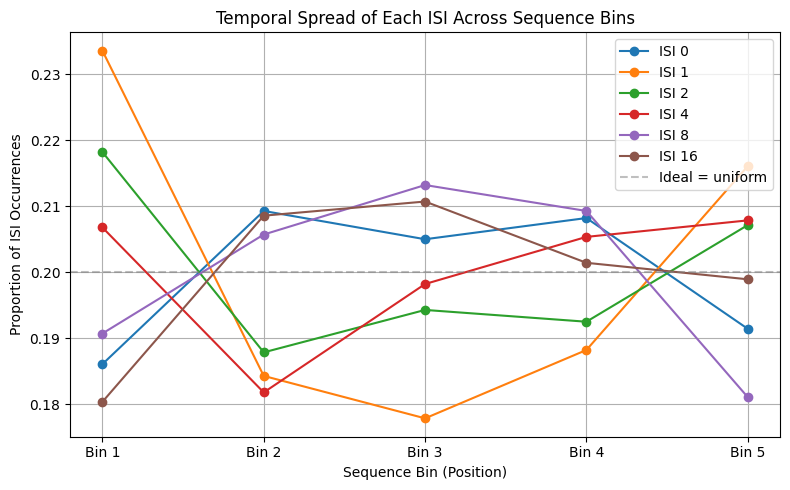

In [65]:
manager.plot_isi_temporal_spread()